<a href="https://colab.research.google.com/github/woo-jungnam/th-deep/blob/main/2001230540_NguyenThanhNam_Buoi3_Bai4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN for Male/Female Face Recognition with TensorFlow

This notebook demonstrates how to build and train a Convolutional Neural Network (CNN) using TensorFlow and Keras to classify faces as male or female. Since a specific dataset for this task isn't directly available in `tf.keras.datasets` without further processing, we'll first create a dummy dataset to make the example runnable.

In [1]:
# 1. Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from PIL import Image

### 2. Prepare Data

We'll create a dummy dataset with two classes: 'male' and 'female'. Each class will have a few placeholder images. In a real scenario, you would replace the data generation part with your actual dataset loading. If your data is organized in directories (e.g., `data/male/` and `data/female/`), `tf.keras.utils.image_dataset_from_directory` is a convenient way to load it.

In [2]:
# Function to generate dummy images and directory structure
def create_dummy_dataset(base_dir='dummy_face_data', img_size=(128, 128), num_images_per_class=50):
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
    os.makedirs(base_dir)

    classes = ['male', 'female']
    for cls in classes:
        class_dir = os.path.join(base_dir, cls)
        os.makedirs(class_dir)
        for i in range(num_images_per_class):
            # Create a simple dummy image (e.g., random noise)
            img_array = np.random.randint(0, 256, size=(img_size[0], img_size[1], 3), dtype=np.uint8)
            img = Image.fromarray(img_array)
            img.save(os.path.join(class_dir, f'image_{i:03d}.jpg'))
    print(f"Dummy dataset created at: {base_dir}")

# Create the dummy dataset
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
DATA_DIR = 'dummy_face_data'
create_dummy_dataset(base_dir=DATA_DIR, img_size=(IMG_HEIGHT, IMG_WIDTH), num_images_per_class=100)

# Load data using image_dataset_from_directory
print("\nLoading dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Configure dataset for performance
def preprocess(image, label):
    image = tf.cast(image / 255.0, tf.float32) # Normalize to [0, 1]
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("\nExample batch from training data:")
for image_batch, labels_batch in train_ds.take(1):
    print(f"Image batch shape: {image_batch.shape}")
    print(f"Labels batch shape: {labels_batch.shape}")

Dummy dataset created at: dummy_face_data

Loading dataset...
Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.
Class names: ['female', 'male']

Example batch from training data:
Image batch shape: (32, 128, 128, 3)
Labels batch shape: (32,)


### 3. Build the CNN Model

We'll define a simple sequential CNN model. This model consists of several convolutional layers (Conv2D) followed by max-pooling layers (MaxPooling2D) for feature extraction. A Flatten layer converts the 2D feature maps into a 1D vector, and dense layers (Dense) are used for classification. A Dropout layer is included to prevent overfitting. For binary classification (male/female), the final dense layer has 1 unit with a sigmoid activation function.

In [3]:
# Define the CNN model
num_classes = len(class_names)

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# Display model summary
print("Model Architecture:")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Model

Now we will train the CNN model using the prepared training and validation datasets. The `fit` method will iterate over the training data for a specified number of `epochs`.

In [4]:
# Train the model
EPOCHS = 10 # You can increase this for better convergence with real data

print(f"\nTraining the model for {EPOCHS} epochs...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Training the model for 10 epochs...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5063 - loss: 0.9977 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4625 - loss: 0.7098 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 888ms/step - accuracy: 0.5688 - loss: 0.6840 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 911ms/step - accuracy: 0.4938 - loss: 0.6979 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5437 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 906ms/step - accuracy: 0.5437 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 933ms/step - accuracy: 0.5375 - loss: 0.6871 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 934ms/step - accuracy: 0.5250 - loss: 0.6958 - val

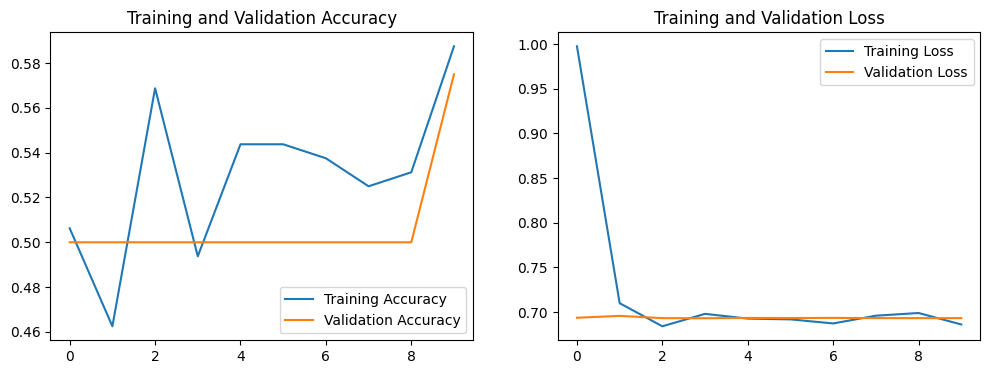

In [5]:
# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### 5. Evaluate the Model and Make Predictions

After training, we evaluate the model's performance on the validation set. We can also use the trained model to make predictions on new, unseen images.


Evaluating the model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5750 - loss: 0.6931
Validation Loss: 0.6931
Validation Accuracy: 0.5750

Making a prediction on a sample image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Predicted probability (for class 'male'): 0.4993
Actual label: female
Predicted label: female


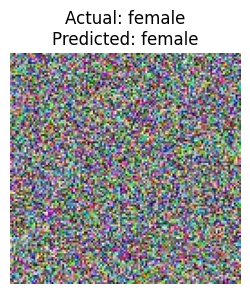

In [6]:
# Evaluate the model on the validation dataset
print("\nEvaluating the model...")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Make a prediction on a sample image
print("\nMaking a prediction on a sample image...")

# Get one batch from validation dataset
for images, labels in val_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    break

# Expand dimensions to create a batch of 1 image
img_array = tf.expand_dims(sample_image, 0)

predictions = model.predict(img_array)

# For binary classification, predictions[0][0] is the probability of the positive class (e.g., 'male')
predicted_class_index = (predictions[0][0] > 0.5).astype(int)
predicted_class_name = class_names[predicted_class_index]

print(f"Predicted probability (for class '{class_names[1]}'): {predictions[0][0]:.4f}")
print(f"Actual label: {class_names[sample_label.numpy()]}")
print(f"Predicted label: {predicted_class_name}")

plt.figure(figsize=(3, 3))
plt.imshow(sample_image.numpy())
plt.title(f"Actual: {class_names[sample_label.numpy()]}\nPredicted: {predicted_class_name}")
plt.axis('off')
plt.show()